In [1]:
# CIFAR : 캐나다 고등 연구소 약자
# 10 : 분류 10개
# - 비행기, 자동차, 새, 고양이, 사슴, 개, 개구리, 말, 배, 트럭
# 이미지 총 6만장. 학습 5만, 테스트 1만
# 크기 32 x 32

In [2]:
# 데이터 생성, 독립/종속 분리, 훈련/테스트 분리
import tensorflow as tf
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

In [3]:
# 10가지 분류명(확인용)
class_names = [
	'airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck'
]

In [4]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
# 콜백
callbacks = [
	EarlyStopping(monitor='val_loss', patience=5,restore_best_weights=True),
	ModelCheckpoint(filepath='best_cifar10_model.keras', monitor='val_accuracy', save_best_only=True, verbose=1),
	ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
]

In [5]:
# 파이프라인
from tensorflow.data import Dataset

DATASET_SIZE = 50000
TRAIN_SIZE = int(DATASET_SIZE * 0.8)
VAL_SIZE = int(DATASET_SIZE * 0.2)

dataset = Dataset.from_tensor_slices((X_train, y_train))
# 섞음 
dataset = dataset.shuffle(buffer_size=DATASET_SIZE)
# 훈련 데이터셋
train_dataset = dataset.take(TRAIN_SIZE)
# 검증 데이터셋
val_dataset = dataset.skip(TRAIN_SIZE)

train_dataset = train_dataset.batch(128).prefetch(tf.data.AUTOTUNE)
val_dataset = val_dataset.batch(128).prefetch(tf.data.AUTOTUNE)

In [6]:
# 데이터 증강 : 이미지를 돌리거나, 색상 반전등과 같이 변형을 한 복사본을 만들어 학습
data_augmentation = tf.keras.Sequential([
	tf.keras.layers.RandomFlip("horizontal"), # 좌우 반전
	tf.keras.layers.RandomRotation(0.2) # 20% 범위 내에서 무작위 회전
])

In [7]:
# 모델 설계
model = tf.keras.models.Sequential([
	tf.keras.Input((32, 32, 3)),
	# 데이터 증강 
	# data_augmentation, 
	# 정규화
	tf.keras.layers.Rescaling(1./255),

	tf.keras.layers.Conv2D(32, (3,3), padding='same', activation='relu'),
	tf.keras.layers.BatchNormalization(),
	tf.keras.layers.Conv2D(32, (3,3), padding='same', activation='relu'),
	tf.keras.layers.MaxPooling2D(2,2),
	tf.keras.layers.Dropout(0.25),
	# 이 때 이미지 크기 16 x 16

	# 블록 2
	tf.keras.layers.Conv2D(64, (3,3), padding='same', activation='relu'),
	tf.keras.layers.BatchNormalization(),
	tf.keras.layers.Conv2D(64, (3,3), padding='same', activation='relu'),
	tf.keras.layers.MaxPooling2D(2,2),
	tf.keras.layers.Dropout(0.25),
	# 이 때 이미지 크기 8 x 8

	# 블록 3
	tf.keras.layers.Conv2D(128, (3,3), padding='same', activation='relu'),
	tf.keras.layers.BatchNormalization(),
	tf.keras.layers.GlobalAveragePooling2D(),

	# 분류기
	tf.keras.layers.Dense(10, activation='softmax')
])

In [8]:
# 모델 설정
model.compile(
	optimizer='adam', 
	loss='sparse_categorical_crossentropy', 
	metrics=['accuracy']
)

In [ ]:
# 학습
history = model.fit(
	train_dataset,
	epochs = 50,
	verbose = 1,
	validation_data=val_dataset,
	callbacks = callbacks,
	batch_size=128,
)

Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step - accuracy: 0.6314 - loss: 1.0306
Epoch 1: val_accuracy improved from 0.12380 to 0.64900, saving model to best_cifar10_model.keras

Epoch 1: finished saving model to best_cifar10_model.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 73s 232ms/step - accuracy: 0.6430 - loss: 1.0060 - val_accuracy: 0.6490 - val_loss: 1.0069 - learning_rate: 0.0010
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step - accuracy: 0.6823 - loss: 0.9054
Epoch 2: val_accuracy improved from 0.64900 to 0.65040, saving model to best_cifar10_model.keras

Epoch 2: finished saving model to best_cifar10_model.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 73s 232ms/step - accuracy: 0.6871 - loss: 0.8908 - val_accuracy: 0.6504 - val_loss: 1.0050 - learning_rate: 0.0010
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - accuracy: 0.7121 - loss: 0.8245
Epoch 3: val_accuracy improved from 0.65040 to 0.67450, saving model to best_cifar10_model.keras

Epoch 3: finished saving model to be

In [ ]:
# 평가
_, acc = model.evaluate(X_test, y_test)
print(f'정확도 : {acc}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.6913 - loss: 0.9099
정확도 : 0.6912999749183655


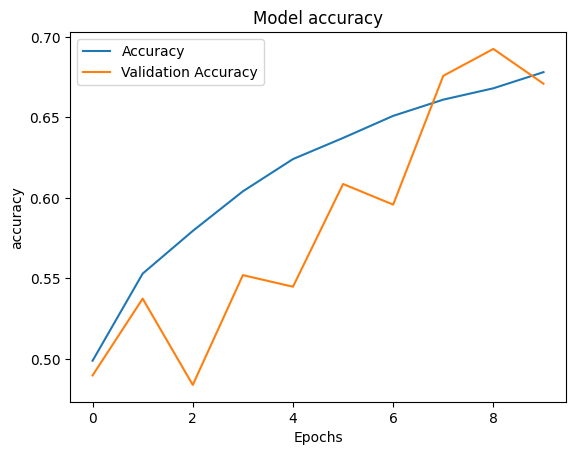

In [ ]:
# 성능 시각화
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], label='Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model accuracy')
plt.xlabel('Epochs')
plt.ylabel('accuracy')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


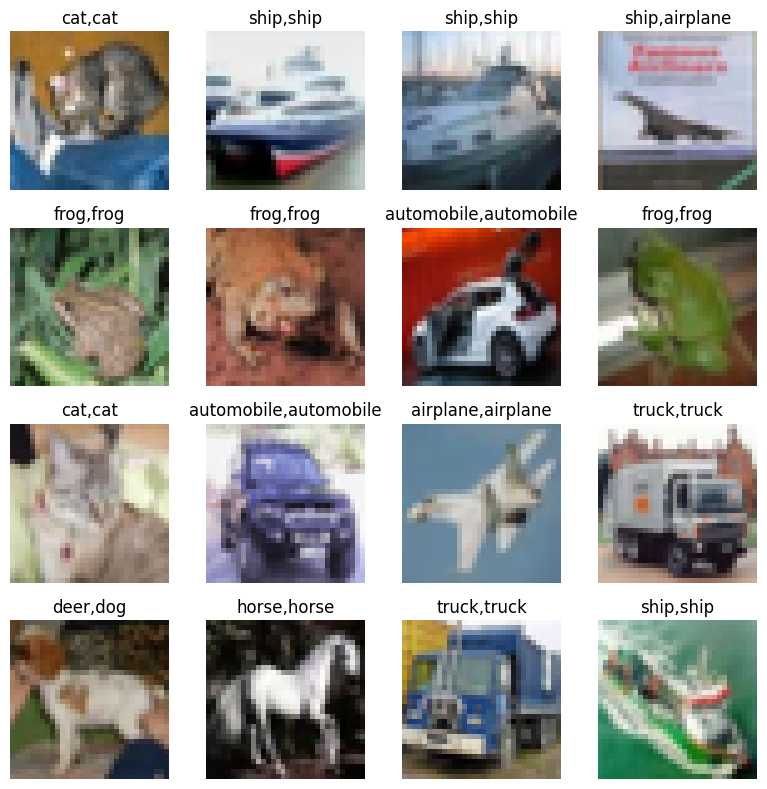

In [ ]:
# 이미지 시각화
predictions = model.predict(X_test[:16])
fig, axes = plt.subplots(4, 4, figsize=(8,8))
for i, ax in enumerate(axes.flat):
	
	ax.imshow(X_test[i])
	predict = predictions[i].argmax()
	true = y_test[i][0]
	ax.set_title(f"{class_names[predict]},{class_names[true]}")
	ax.axis('off')

plt.tight_layout()
plt.show()


In [ ]:
import cv2
import numpy as np
# 예측
def model_predict_idx(model, img_path):

	img = cv2.imread(img_path, cv2.IMREAD_COLOR)

	resize_img = cv2.resize(img, (32, 32))

	predict = model.predict(np.array([resize_img]))

	result = np.argmax(predict)
	return class_names[result]

In [ ]:
# 예측
result = model_predict_idx(model, '../data/img/cifar10_0_1.png')
print(f'airplain? {result}')
result = model_predict_idx(model, '../data/img/cifar10_9_1.png')
print(f'truck? {result}')
result = model_predict_idx(model, '../data/img/cifar10_9_2.png')
print(f'truck? {result}')


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
airplain? airplane
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
truck? automobile
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
truck? automobile
